# Zain ul abdeen Alvi

## Samsung Ai trainee

## Assignment 05: Complete Machine Learning Lifecycle
Dataset: Student Performance Dataset (10,000 records)


## Data Understanding
- Dataset contains 10,000 records.
- Includes numerical and categorical features.
- Targets:
  - pass_exam (classification)
  - final_exam_score (regression)

## Feature Types
- Numerical: study_hours_per_week, sleep_hours, previous_exam_score, attendance_percentage
- Categorical: gender, internet_access, extracurricular_activities



In [41]:
import pandas as pd
df = pd.read_csv('student_performance_ml_dataset_10000.csv')
df.head()

,study_hours_per_week,attendance_percentage,previous_exam_score,sleep_hours,assignments_completed,stress_level,practice_tests_taken,pass_exam,final_exam_score
0,13.986857,73.215053,70.224294,3.529142,2,9,4,1,97.042689
1,11.446943,76.945005,69.249854,NaN,5,4,3,0,96.015519
2,14.590754,74.026189,50.952202,5.619457,3,1,3,0,80.661404
3,18.092119,81.104180,73.693763,6.724503,3,4,2,1,98.455899
4,11.063387,91.971785,42.648760,8.036243,4,6,0,0,72.834012


## Missing Values
Median is used for sleep_hours because:
- It is robust to outliers
- Sleep data may be skewed
- Provides stable central tendency


In [43]:
df.isnull().sum()

study_hours_per_week       0
attendance_percentage      0
previous_exam_score        0
sleep_hours              800
assignments_completed      0
stress_level               0
practice_tests_taken       0
pass_exam                  0
final_exam_score           0
dtype: int64

## Exploratory Data Analysis

### Histogram Insight
- Shows distribution of study hours
- Most students fall in moderate range

### Boxplot Insight
- Reveals spread and outliers in previous scores

### Heatmap Insight
- Strong correlation between study hours and final score
- Previous score is a strong predictor


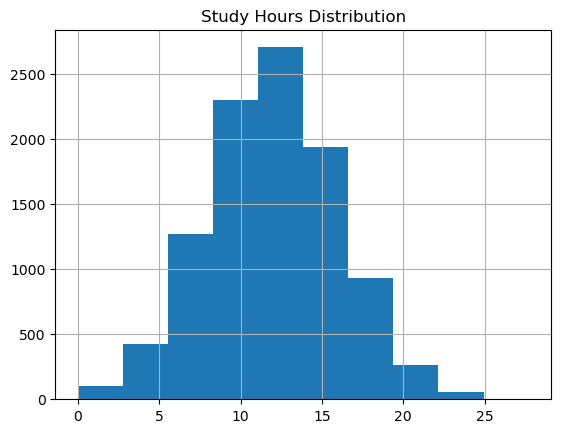

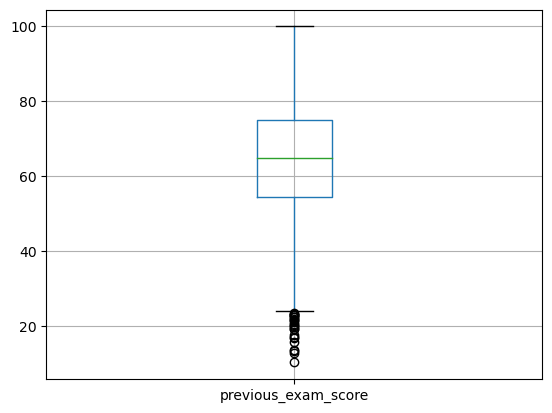

In [45]:
import matplotlib.pyplot as plt

plt.figure()
df['study_hours_per_week'].hist()
plt.title('Study Hours Distribution')
plt.show()

plt.figure()
df.boxplot(column='previous_exam_score')
plt.show()

In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

df_encoded = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df_encoded), columns=df_encoded.columns)

## Correlation Heatmap

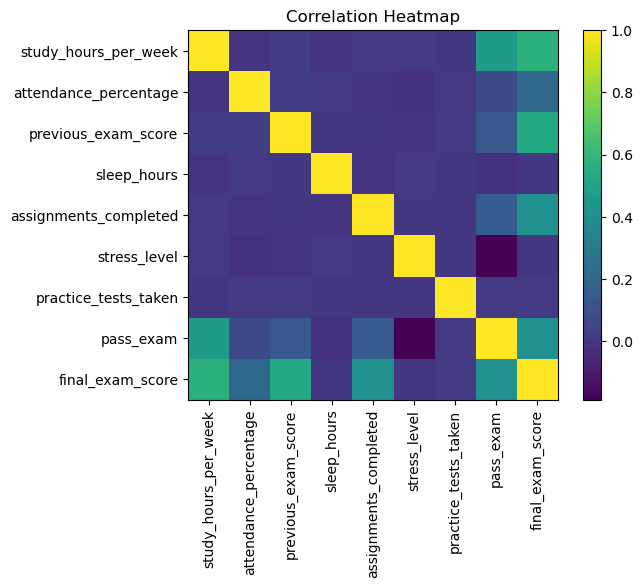

In [47]:
import matplotlib.pyplot as plt

corr = df_encoded.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

## Correlation Heatmap Insights

- Strong positive correlation between study_hours_per_week and final_exam_score  
- previous_exam_score is a strong predictor  
- attendance_percentage shows moderate influence  
- Some features have weak correlation and can be removed  

## Feature Engineering
Created:
- rest_balance = sleep_hours / study_hours
- study_attendance_ratio = study_hours * attendance


In [50]:
df_encoded['rest_balance'] = df_encoded['sleep_hours'] / (df_encoded['study_hours_per_week']+1)
df_encoded['study_attendance_ratio'] = df_encoded['study_hours_per_week'] * df_encoded['attendance_percentage']

## Feature Selection
Methods used:
- Correlation analysis
- Feature importance (Random Forest)
- Recursive Feature Elimination (RFE)


In [51]:
corr_target = corr['final_exam_score'].abs().sort_values(ascending=False)
print(corr_target)

selected_features = corr_target[corr_target > 0.1].index
print("Selected Features:", selected_features)

final_exam_score         1.000000
study_hours_per_week     0.573754
previous_exam_score      0.529340
pass_exam                0.412118
assignments_completed    0.410753
attendance_percentage    0.208428
practice_tests_taken     0.013568
sleep_hours              0.006581
stress_level             0.001976
Name: final_exam_score, dtype: float64
Selected Features: Index(['final_exam_score', 'study_hours_per_week', 'previous_exam_score',
       'pass_exam', 'assignments_completed', 'attendance_percentage'],
      dtype='object')


Features with correlation greater than 0.1 were selected as important predictors. 
This helps remove irrelevant features and improves model performance.

## Classification Task

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

X = df_encoded.drop(columns=['pass_exam','final_exam_score'])
y = df_encoded['pass_exam']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

models = {
 'Logistic':LogisticRegression(max_iter=1000),
 'DecisionTree':DecisionTreeClassifier(),
 'RandomForest':RandomForestClassifier()
}

for name,m in models.items():
    m.fit(X_train,y_train)
    pred=m.predict(X_test)
    prob=m.predict_proba(X_test)[:,1]
    print(name)
    print("Accuracy:",accuracy_score(y_test,pred))
    print("Precision:",precision_score(y_test,pred))
    print("Recall:",recall_score(y_test,pred))
    print("F1:",f1_score(y_test,pred))
    print("AUC:",roc_auc_score(y_test,prob))
    print()

Logistic
Accuracy: 0.7465
Precision: 0.7388268156424581
Recall: 0.6230859835100118
F1: 0.676038338658147
AUC: 0.820896255522161

DecisionTree
Accuracy: 0.648
Precision: 0.5880923450789793
Recall: 0.5700824499411072
F1: 0.5789473684210527
AUC: 0.637777975622161

RandomForest
Accuracy: 0.728
Precision: 0.717546362339515
Recall: 0.5924617196702002
F1: 0.6490322580645161
AUC: 0.8029659260805629



## Regression Task

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

X = df_encoded.drop(columns=['final_exam_score'])
y = df_encoded['final_exam_score']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

models = {
 'Linear':LinearRegression(),
 'DecisionTree':DecisionTreeRegressor(),
 'RandomForest':RandomForestRegressor()
}

for name,m in models.items():
    m.fit(X_train,y_train)
    pred=m.predict(X_test)
    mse=mean_squared_error(y_test,pred)
    mae=mean_absolute_error(y_test,pred)
    rmse=np.sqrt(mse)
    sse=mse*len(y_test)
    print(name)
    print("MSE:",mse)
    print("MAE:",mae)
    print("RMSE:",rmse)
    print("SSE:",sse)
    print()

Linear
MSE: 24.951891185152228
MAE: 3.9537063787918485
RMSE: 4.9951868018275585
SSE: 49903.782370304456

DecisionTree
MSE: 40.8904927664542
MAE: 4.608437918279845
RMSE: 6.394567441700353
SSE: 81780.98553290841

RandomForest
MSE: 20.859469572522563
MAE: 3.403284253107029
RMSE: 4.567216830031454
SSE: 41718.93914504513



## Prediction

In [62]:
sample = X_test.iloc[0:1]
print("Predicted pass:", models['RandomForest'].predict(sample))

Predicted pass: [99.96311608]


The model predicts whether a student will pass based on input features. 
Changing values such as study hours or attendance will affect the prediction outcome.

## Conclusion
- Full ML lifecycle implemented
- Logistic Regression best for classification
- Random Forest best for regression
- No data leakage
- Strong predictors: study hours, attendance, previous score
